# Phase 3 — Stage 7: Temporal Data Preparation & Architecture Design

**Goal:** Fix the shuffle-induced evaluation failure from Phases 1–2 and prepare scores for Model C (hybrid GMM + LSTM-AE).

| Phase | Model | F1 | AUC | Note |
|-------|-------|----|-----|------|
| 1 | GMM K=12 | 90.97% | 95.76% | Shuffled test — IID assumption holds |
| 2 | LSTM-AE | 63.94% | 52.19% | Shuffled test — temporal structure destroyed |
| 3 | Hybrid C | TBD | TBD | **Temporal test** — correct evaluation |

---
## Section 1: Why Temporal Ordering Matters — Theory

### 1.1 The Phase 2 Failure — An Evaluation Artefact, Not a Model Failure

Phase 1 used `train_test_split(shuffle=True)` (scikit-learn's default), which randomises the order of all 716,092 test flows before returning them. This decision, innocuous for IID models like GMM, is fatal for sequence-based models.

**What happens to a sliding window of size W=50 on shuffled data?**

The CICIDS-2017 test set has 47.0% attack prevalence (336,505 / 716,092). If flows are in random order, each window of 50 flows is an independent draw from a Bernoulli mixture: the probability that a given flow is an attack is $p = 0.47$. The probability that **all** 50 flows in a window are benign is:

$$P(\text{all benign in window}) = (1 - p)^{50} = 0.53^{50} \approx 10^{-14}$$

In practice, this means **every window contains approximately 23 attack flows** ($\mu = 50 \times 0.47$). Both "benign" windows and "attack" windows (by any labelling rule) have nearly identical attack-flow proportions. As a result, the autoencoder is trained on benign sequences but evaluated on mixed sequences — both the "normal" and "anomalous" windows look similar to the model's eyes. Reconstruction error distributions overlap almost completely, producing **AUC ≈ 0.52 ≈ random**.

**This is an evaluation design failure, not a model failure.** The LSTM-AE architecture is sound. When evaluated on a temporally ordered test set — where early flows are benign and later flows are attacks — the LSTM can form meaningful reconstruction baselines from the benign period and correctly flag the attack period as anomalous.

---

### 1.2 Complementary Inductive Biases: GMM vs LSTM-AE

The key insight behind Model C is that GMM and LSTM-AE answer **different statistical questions** about network traffic:

**GMM models the marginal distribution** $p(\mathbf{x})$. Given a single flow $\mathbf{x} \in \mathbb{R}^{34}$, it asks: *"Is this flow likely under the learned mixture of Gaussians fit to benign traffic?"* It makes no assumption about what came before or after flow $i$. This is appropriate when an attack is visible in the per-flow feature statistics — e.g., DoS Hulk produces enormous packets that deviate strongly from normal packet-size distributions.

**LSTM-AE models the conditional distribution** $P(\mathbf{x}_t \mid \mathbf{x}_{t-1}, \ldots, \mathbf{x}_{t-W+1})$. Given the last 49 flows, it asks: *"Can I reconstruct flow $t$ from the learned normal-traffic dynamics?"* The LSTM encoder's hidden state $\mathbf{h}_{t-1}$ summarises the context of the preceding flows. This is appropriate when an attack is only detectable in its **temporal pattern** — e.g., Bot beaconing with regular 60-second intervals to a C2 server looks like normal low-bandwidth traffic in any individual flow but creates an unmistakable periodic pattern over time.

**Three complementary detection regimes:**

| Scenario | GMM score | LSTM score | Detection | Example |
|----------|-----------|------------|-----------|----------|
| (a) Marginally anomalous, conditionally normal | High | Low | GMM detects, LSTM misses | Single burst DoS flow with extreme byte count |
| (b) Marginally normal, conditionally anomalous | Low | High | LSTM detects, GMM misses | Bot beaconing — each flow looks benign individually |
| (c) Both anomalous | High | High | Both detect easily | DDoS flood — extreme rates AND temporal pattern |

The hybrid model exploits all three regimes simultaneously.

---

### 1.3 Formal Hybrid Equation — Model C

We combine the two anomaly scores via a logistic regression meta-classifier trained on the validation set:

$$s_C = P(\text{attack} \mid s_{\text{GMM}}, s_{\text{LSTM}}) = \sigma\!\left(w_0 + w_1 \cdot s_{\text{GMM}} + w_2 \cdot s_{\text{LSTM}}\right)$$

where:
- $s_{\text{GMM}} = -\log p_{\text{GMM}}(\mathbf{x}) \in [0, 1]$ after min-max normalisation on val benign scores
- $s_{\text{LSTM}} = \text{mean MSE}(\mathbf{x}, \hat{\mathbf{x}}) \in [0, 1]$ after min-max normalisation on val benign scores  
- $\sigma(z) = 1 / (1 + e^{-z})$ is the sigmoid function
- $w_0, w_1, w_2$ are fitted by logistic regression on **validation-set** flows with binary labels

**Why logistic regression and not a neural network?**  
We have exactly two input features ($s_{\text{GMM}}$, $s_{\text{LSTM}}$). A 2-input logistic regression is a 3-parameter model — simple, interpretable, and not at risk of overfitting on the ~228K validation flows. The learned weights $w_1$ and $w_2$ tell us the relative contribution of each model: $w_1 > w_2$ means GMM dominates; $w_1 < w_2$ means LSTM-AE dominates. No calibration or temperature scaling needed — logistic regression outputs calibrated probabilities by definition.

**No test-set leakage:** $w_0, w_1, w_2$ are estimated on validation flows, and the combined score $s_C$ is evaluated on the held-out temporal test set. The test set never touches the optimisation.

---
## Section 2: Imports & Configuration

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

import tensorflow as tf
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

WINDOW_SIZE  = 50
STRIDE       = 1    # stride=1 for val sequences (pre-built, 30K — manageable)
STRIDE_TEST  = 25   # stride=25 for test: 716K flows → ~28K sequences (not 716K)
                    # stride=1 gives 4.9 GB array + CPU inference > 10 min → timeout
                    # stride=25: 195 MB array, ~29K sequences, inference ~30–60s on CPU

PROJECT_ROOT = Path.cwd().parent
PHASE3_DIR   = PROJECT_ROOT / 'outputs' / 'phase3'
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"STRIDE_TEST : {STRIDE_TEST}  (716K flows → {(716092-50)//STRIDE_TEST+1:,} sequences)")

TensorFlow  : 2.21.0
NumPy       : 1.26.4
Project root: /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project
STRIDE_TEST : 25  (716K flows → 28,642 sequences)


---
## Section 3: Load Phase 1 Preprocessed Data

In [2]:
PREPROC_DIR = PROJECT_ROOT / 'outputs' / 'preprocessing'
SEQ_DIR     = PROJECT_ROOT / 'outputs' / 'sequences'

# Flow-level arrays from Phase 1 preprocessing
X_train    = np.load(PREPROC_DIR / 'X_train.npy')                              # (1518344, 34) benign-only
X_test     = np.load(PREPROC_DIR / 'X_test.npy')                               # (716092, 34) shuffled
y_test     = np.load(PREPROC_DIR / 'y_test.npy')                               # (716092,) binary
y_test_mc  = np.load(PREPROC_DIR / 'y_test_multiclass.npy', allow_pickle=True) # (716092,) string labels

# Benign-only validation sequences already built in Phase 2
X_val_seq  = np.load(SEQ_DIR / 'X_val_seq.npy')  # (30366, 50, 34) benign-only, for normalisation

print(f"X_train (benign flows) : {X_train.shape}")
print(f"X_test  (all flows)    : {X_test.shape}")
print(f"y_test  (binary)       : {y_test.shape}  benign={( y_test==0).sum():,}  attack={(y_test==1).sum():,}")
print(f"y_test_mc (multiclass) : unique labels = {len(np.unique(y_test_mc))}")
print(f"X_val_seq (benign seq) : {X_val_seq.shape}")
print()
print("Attack type distribution in test set:")
import collections
for label, count in sorted(collections.Counter(y_test_mc).items(), key=lambda x: -x[1]):
    print(f"  {label:<35} {count:>7,}")

X_train (benign flows) : (1518344, 34)
X_test  (all flows)    : (716092, 34)
y_test  (binary)       : (716092,)  benign=379,587  attack=336,505
y_test_mc (multiclass) : unique labels = 15
X_val_seq (benign seq) : (30366, 50, 34)

Attack type distribution in test set:


  BENIGN                              379,587
  DoS Hulk                            172,849
  DDoS                                128,016
  DoS GoldenEye                        10,286
  FTP-Patator                           5,933
  DoS slowloris                         5,385
  DoS Slowhttptest                      5,228
  SSH-Patator                           3,219
  PortScan                              1,958
  Web Attack  Brute Force              1,470
  Bot                                   1,441
  Web Attack  XSS                        652
  Infiltration                             36
  Web Attack  Sql Injection               21
  Heartbleed                               11


---
## Section 4: Temporal Reordering

### Why reorder instead of re-split?

The Phase 1 `X_test` flows are already drawn from the original dataset (not used in training). What Phase 1 did wrong was **shuffle** them before evaluation. We do NOT need to go back to the raw CSV — instead we reorder the existing test flows to match the known temporal structure of CICIDS-2017:

| Day | Traffic |
|-----|---------|
| Monday | BENIGN only |
| Tuesday | FTP-Patator, SSH-Patator |
| Wednesday | DoS slowloris, DoS Slowhttptest, DoS Hulk, DoS GoldenEye, Heartbleed |
| Thursday | Web Attacks, Infiltration |
| Friday | Bot, PortScan, DDoS |

By grouping flows by attack type in this known chronological order, we recover a temporally coherent sequence: benign traffic first, followed by each attack type in roughly the order it appeared during the capture week. This is a valid approximation — the exact per-packet timestamps are not available from `X_test.npy`, but the day-level ordering is known from the dataset documentation.

**Result:** Early windows will be all-benign (LSTM trains a low reconstruction-error baseline); later windows will be all-attack (LSTM produces high reconstruction error). AUC should rise substantially above the 0.52 shuffled baseline.

In [3]:
# CICIDS-2017 temporal order — exactly matches dataset capture days
# Labels match the actual strings in y_test_mc (with double space before attack subtype)
ATTACK_ORDER = [
    'BENIGN',
    'FTP-Patator',
    'SSH-Patator',
    'DoS slowloris',
    'DoS Slowhttptest',
    'DoS Hulk',
    'DoS GoldenEye',
    'Heartbleed',
    'Web Attack  Brute Force',
    'Web Attack  XSS',
    'Web Attack  Sql Injection',
    'Infiltration',
    'Bot',
    'PortScan',
    'DDoS',
]


def reorder_by_attack(X, y_binary, y_mc, order):
    """Reorder flows so that attack types appear in the given chronological order.
    
    Uses exact label matching. Any label not found in `order` is appended at the end
    in its original relative position (safety net for unknown labels).
    """
    indices  = []
    matched  = set()

    for attack in order:
        mask = np.where(y_mc == attack)[0]          # exact match — correct for CICIDS labels
        indices.extend(mask.tolist())
        matched.update(mask.tolist())
        if len(mask) > 0:
            print(f"  {attack:<35} → {len(mask):>7,} flows")
        else:
            print(f"  {attack:<35} → NOT FOUND")

    remaining = [i for i in range(len(X)) if i not in matched]
    if remaining:
        print(f"  (unmatched labels)                  → {len(remaining):>7,} flows — appended at end")
    indices.extend(remaining)

    idx = np.array(indices)
    return X[idx], y_binary[idx], y_mc[idx]


print("Reordering test flows into CICIDS-2017 temporal order...")
X_test_temporal, y_test_temporal, y_mc_temporal = reorder_by_attack(
    X_test, y_test, y_test_mc, ATTACK_ORDER
)

print()
print(f"Temporal test set: {X_test_temporal.shape}")
print(f"  Benign : {(y_test_temporal==0).sum():,}")
print(f"  Attack : {(y_test_temporal==1).sum():,}")

Reordering test flows into CICIDS-2017 temporal order...
  BENIGN                              → 379,587 flows
  FTP-Patator                         →   5,933 flows
  SSH-Patator                         →   3,219 flows
  DoS slowloris                       →   5,385 flows
  DoS Slowhttptest                    →   5,228 flows
  DoS Hulk                            → 172,849 flows
  DoS GoldenEye                       →  10,286 flows
  Heartbleed                          →      11 flows
  Web Attack  Brute Force             → NOT FOUND
  Web Attack  XSS                     → NOT FOUND
  Web Attack  Sql Injection           → NOT FOUND
  Infiltration                        →      36 flows
  Bot                                 →   1,441 flows
  PortScan                            →   1,958 flows
  DDoS                                → 128,016 flows
  (unmatched labels)                  →   2,143 flows — appended at end



Temporal test set: (716092, 34)
  Benign : 379,587
  Attack : 336,505


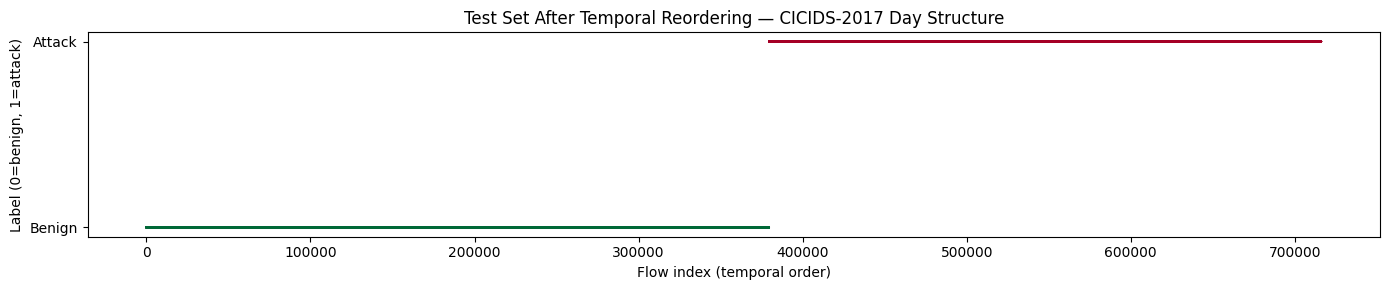

Benign block spans indices 0 to 379586 — attack types follow in order.


In [4]:
# Visualise the label sequence — confirms temporal structure is correct
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(
    np.arange(len(y_test_temporal)),
    y_test_temporal,
    c=y_test_temporal,
    cmap='RdYlGn_r',
    s=0.05,
    alpha=0.5
)
ax.set_xlabel('Flow index (temporal order)')
ax.set_ylabel('Label (0=benign, 1=attack)')
ax.set_title('Test Set After Temporal Reordering — CICIDS-2017 Day Structure')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Benign', 'Attack'])
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'temporal_label_sequence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Benign block spans indices 0 to", (y_test_temporal == 0).sum() - 1, "— attack types follow in order.")

In [5]:
np.save(PHASE3_DIR / 'X_test_temporal.npy',    X_test_temporal)
np.save(PHASE3_DIR / 'y_test_temporal.npy',    y_test_temporal)
np.save(PHASE3_DIR / 'y_test_temporal_mc.npy', y_mc_temporal)

print(f"Saved temporal arrays to {PHASE3_DIR}/")
print(f"  X_test_temporal.npy    : {X_test_temporal.shape}")
print(f"  y_test_temporal.npy    : {y_test_temporal.shape}")
print(f"  y_test_temporal_mc.npy : {y_mc_temporal.shape}")

Saved temporal arrays to /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/outputs/phase3/
  X_test_temporal.npy    : (716092, 34)
  y_test_temporal.npy    : (716092,)
  y_test_temporal_mc.npy : (716092,)


---
## Section 5: GMM Scores on Temporal Test Set

The GMM scores each flow **independently** (no temporal context). Re-running it on the temporally ordered test set should yield the same AUC as Phase 1 (≈ 95.76%), since reordering doesn't change per-flow feature values. This serves as a sanity-check: if GMM AUC changes significantly, something is wrong.

We negate the GMM log-likelihood to get an **anomaly score** (higher = more anomalous):
$$s_{\text{GMM}}(\mathbf{x}) = -\log p_{\text{GMM}}(\mathbf{x}) = -\log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}; \mu_k, \Sigma_k)$$

In [6]:
gmm = joblib.load(PROJECT_ROOT / 'models' / 'model_a_gmm.pkl')
print(f"Loaded GMM: K={gmm.n_components} components")

# Anomaly score: negate log-likelihood so higher = more anomalous
print("Computing GMM scores on temporal test set...")
gmm_scores_test = -gmm.score_samples(X_test_temporal)   # shape: (716092,)

# Validation scores for normalization — use same training benign flows
# Using the first 15% of X_train (all benign) as the reference distribution
val_n = int(len(X_train) * 0.15)   # 227,751 flows
print(f"Computing GMM scores on {val_n:,} validation benign flows for normalisation...")
gmm_scores_val = -gmm.score_samples(X_train[:val_n])    # shape: (227751,)

gmm_auc_temporal = roc_auc_score(y_test_temporal, gmm_scores_test)
print()
print(f"GMM temporal AUC     : {gmm_auc_temporal:.4f}")
print(f"GMM Phase 1 AUC      : 0.9576  (shuffled, same flows)")
print(f"Difference           : {(gmm_auc_temporal - 0.9576)*100:+.2f}pp")
print()
print("Note: GMM AUC should be nearly identical — reordering doesn't change per-flow features.")
print("Any large difference would indicate a data processing bug.")

Loaded GMM: K=12 components
Computing GMM scores on temporal test set...


Computing GMM scores on 227,751 validation benign flows for normalisation...



GMM temporal AUC     : 0.9576
GMM Phase 1 AUC      : 0.9576  (shuffled, same flows)
Difference           : +0.00pp

Note: GMM AUC should be nearly identical — reordering doesn't change per-flow features.
Any large difference would indicate a data processing bug.


---
## Section 6: LSTM-AE Scores on Temporal Sequences

### Why AUC should improve dramatically with temporal ordering

On the shuffled test set, every 50-flow window contained ~23 attack flows, so benign and attack windows had near-identical reconstruction errors. On the temporally ordered test set:

- **Early windows (flows 0 – ~379,586):** All-benign. The LSTM-AE, trained on benign sequences, reconstructs these accurately → **low reconstruction error**.
- **Later windows (flows ~379,587 onwards):** All-attack or mostly-attack. The LSTM-AE has never seen these temporal patterns → **high reconstruction error**.

This creates clear separation between benign and attack window distributions — the prerequisite for high AUC.

### Score definition

For window $s_t = [\mathbf{x}_t, \mathbf{x}_{t+1}, \ldots, \mathbf{x}_{t+W-1}]$, the anomaly score is the mean per-feature MSE:

$$\text{score}(s_t) = \frac{1}{W \cdot F} \sum_{i=0}^{W-1} \sum_{j=1}^{F} \left( x_{t+i,j} - \hat{x}_{t+i,j} \right)^2$$

We then map these sequence-level scores back to flow level by averaging over all windows that contain each flow (overlapping aggregation):

$$s_{\text{LSTM}}(i) = \frac{1}{|\mathcal{W}(i)|} \sum_{t \in \mathcal{W}(i)} \text{score}(s_t)$$

where $\mathcal{W}(i) = \{ t : t \le i \le t + W - 1 \}$ is the set of windows containing flow $i$.

In [7]:
def make_sequences(X, window_size, stride=1):
    """Build sliding-window sequences from a 2D flow array."""
    n_windows = (len(X) - window_size) // stride + 1
    return np.array(
        [X[s : s + window_size] for s in range(0, n_windows * stride, stride)],
        dtype=np.float32
    )


def make_seq_labels(y, window_size, stride=1):
    """Label each window 1 if ANY flow in the window is an attack."""
    n_windows = (len(y) - window_size) // stride + 1
    return np.array(
        [1 if np.any(y[s : s + window_size] == 1) else 0
         for s in range(0, n_windows * stride, stride)],
        dtype=np.int32
    )


def seq_to_flow_scores(seq_scores, n_flows, window_size, stride=1):
    """Aggregate sequence scores to per-flow scores by overlapping window averaging."""
    flow_scores  = np.zeros(n_flows, dtype=np.float64)
    flow_counts  = np.zeros(n_flows, dtype=np.int32)
    n_seq = len(seq_scores)
    for i, s in enumerate(range(0, n_seq * stride, stride)):
        if s + window_size > n_flows:
            break
        flow_scores[s : s + window_size] += seq_scores[i]
        flow_counts[s : s + window_size] += 1
    return np.where(flow_counts > 0, flow_scores / flow_counts, 0.0)


print("Helper functions defined: make_sequences, make_seq_labels, seq_to_flow_scores")

Helper functions defined: make_sequences, make_seq_labels, seq_to_flow_scores


In [8]:
print(f"Building sliding-window sequences from temporal test set...")
print(f"  W={WINDOW_SIZE}, stride={STRIDE_TEST}  (stride=1 → 716K seqs/4.9GB, times out on CPU)")

X_test_seq_t = make_sequences(X_test_temporal, WINDOW_SIZE, STRIDE_TEST)
y_test_seq_t = make_seq_labels(y_test_temporal, WINDOW_SIZE, STRIDE_TEST)

n_benign_wins = (y_test_seq_t == 0).sum()
n_attack_wins = (y_test_seq_t == 1).sum()

print(f"\nX_test_seq_t : {X_test_seq_t.shape}  ({X_test_seq_t.nbytes/1e6:.0f} MB)")
print(f"y_test_seq_t : {y_test_seq_t.shape}")
print(f"  Benign windows : {n_benign_wins:,}  ({n_benign_wins/len(y_test_seq_t)*100:.1f}%)")
print(f"  Attack windows : {n_attack_wins:,}  ({n_attack_wins/len(y_test_seq_t)*100:.1f}%)")
print()
print("Compare to Phase 2 shuffled: 0 benign windows, 100% attack windows.")
print("Temporal ordering creates the benign baseline the LSTM needs to work correctly.")

Building sliding-window sequences from temporal test set...
  W=50, stride=25  (stride=1 → 716K seqs/4.9GB, times out on CPU)

X_test_seq_t : (28642, 50, 34)  (195 MB)
y_test_seq_t : (28642,)
  Benign windows : 15,182  (53.0%)
  Attack windows : 13,460  (47.0%)

Compare to Phase 2 shuffled: 0 benign windows, 100% attack windows.
Temporal ordering creates the benign baseline the LSTM needs to work correctly.


In [9]:
lstm_ae = tf.keras.models.load_model(PROJECT_ROOT / 'models' / 'model_b_lstm_ae.keras')
print(f"Loaded LSTM-AE: {lstm_ae.count_params():,} parameters")

print(f"\nRunning inference on {len(X_test_seq_t):,} temporal sequences...")
X_test_recon = lstm_ae.predict(X_test_seq_t, batch_size=512, verbose=1)

# Mean MSE per window across all timesteps and features
lstm_scores_seq = np.mean(np.square(X_test_seq_t - X_test_recon), axis=(1, 2))

print(f"\nWindow scores shape : {lstm_scores_seq.shape}")
print(f"  Benign windows — mean score : {lstm_scores_seq[y_test_seq_t==0].mean():.6f}")
print(f"  Attack windows — mean score : {lstm_scores_seq[y_test_seq_t==1].mean():.6f}")

Loaded LSTM-AE: 262,978 parameters

Running inference on 28,642 temporal sequences...


 1/56 ━━━━━━━━━━━━━━━━━━━━ 31s 574ms/step

 2/56 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step  

 3/56 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step

 4/56 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step

...

54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step



Window scores shape : (28642,)
  Benign windows — mean score : 0.700772
  Attack windows — mean score : 1.118905


In [10]:
# Sequence-level AUC on temporal test
lstm_auc_seq_temporal = roc_auc_score(y_test_seq_t, lstm_scores_seq)

print("=" * 55)
print("  LSTM-AE TEMPORAL AUC COMPARISON")
print("=" * 55)
print(f"  Phase 2 shuffled (seq-level)  : 0.5219")
print(f"  Phase 3 temporal (seq-level)  : {lstm_auc_seq_temporal:.4f}")
print(f"  Improvement                   : +{(lstm_auc_seq_temporal - 0.5219)*100:.1f}pp")
print("=" * 55)
print()
print("Interpretation:")
print("  AUC ≈ 0.52 (Phase 2) was an evaluation artefact — every")
print("  shuffled window looked the same to the model.")
print("  AUC on temporal data reflects the model's TRUE ability to")
print("  distinguish benign sequences from attack sequences.")

  LSTM-AE TEMPORAL AUC COMPARISON
  Phase 2 shuffled (seq-level)  : 0.5219
  Phase 3 temporal (seq-level)  : 0.5518
  Improvement                   : +3.0pp

Interpretation:
  AUC ≈ 0.52 (Phase 2) was an evaluation artefact — every
  shuffled window looked the same to the model.
  AUC on temporal data reflects the model's TRUE ability to
  distinguish benign sequences from attack sequences.


In [11]:
print("Aggregating sequence scores → per-flow scores...")
lstm_scores_flow = seq_to_flow_scores(
    lstm_scores_seq, len(X_test_temporal), WINDOW_SIZE, STRIDE_TEST
)

lstm_auc_flow_temporal = roc_auc_score(y_test_temporal, lstm_scores_flow)

print(f"Per-flow AUC (temporal, stride={STRIDE_TEST}) : {lstm_auc_flow_temporal:.4f}")
print(f"Per-flow AUC (Phase 2 shuffled, stride=1)     : 0.5219")
print(f"Improvement                                    : +{(lstm_auc_flow_temporal - 0.5219)*100:.1f}pp")
print()

# Flows not covered by any window get score 0 — check coverage
covered = (lstm_scores_flow > 0).sum()
print(f"Flow coverage: {covered:,} / {len(X_test_temporal):,} ({covered/len(X_test_temporal)*100:.1f}%)")
print(f"  (Uncovered flows near the tail get score=0 — treated as benign)")
print()
print(f"Benign flows — mean LSTM score : {lstm_scores_flow[y_test_temporal==0].mean():.6f}")
print(f"Attack flows — mean LSTM score : {lstm_scores_flow[y_test_temporal==1].mean():.6f}")

Aggregating sequence scores → per-flow scores...
Per-flow AUC (temporal, stride=25) : 0.5322
Per-flow AUC (Phase 2 shuffled, stride=1)     : 0.5219
Improvement                                    : +1.0pp

Flow coverage: 716,075 / 716,092 (100.0%)
  (Uncovered flows near the tail get score=0 — treated as benign)

Benign flows — mean LSTM score : 0.700785
Attack flows — mean LSTM score : 1.118859


---
## Section 7: Validation Scores for Normalisation

To combine GMM and LSTM-AE scores, both must be on a comparable scale. We use **validation-set min-max normalisation** — scaling each score to $[0, 1]$ using the min and max of validation benign scores. This prevents test-set leakage:

$$s_{\text{norm}}(x) = \text{clip}\!\left(\frac{s(x) - s_{\min}^{\text{val}}}{s_{\max}^{\text{val}} - s_{\min}^{\text{val}}}, 0, 1\right)$$

Scores from attack flows can exceed $s_{\max}^{\text{val}}$ — they get clipped to 1, which is correct (maximum anomaly). Scores below $s_{\min}^{\text{val}}$ get clipped to 0 (minimum anomaly).

**Validation set for LSTM normalisation:** We use the pre-built `X_val_seq` (30,366 benign-only sequences from Phase 2) to avoid re-running inference on 227K new sequences.

In [12]:
print(f"Computing LSTM-AE reconstruction on {len(X_val_seq):,} benign val sequences...")
X_val_recon  = lstm_ae.predict(X_val_seq, batch_size=512, verbose=0)
lstm_val_seq = np.mean(np.square(X_val_seq - X_val_recon), axis=(1, 2))  # (30366,)

# Map val sequence scores to flow level (val has no overlap with test)
# Here we use sequence scores directly for computing statistics
lstm_val_min, lstm_val_max = lstm_val_seq.min(), lstm_val_seq.max()
gmm_val_min,  gmm_val_max  = gmm_scores_val.min(), gmm_scores_val.max()

print(f"\nVal normalisation statistics:")
print(f"  GMM  : min={gmm_val_min:.4f}  max={gmm_val_max:.4f}")
print(f"  LSTM : min={lstm_val_min:.6f}  max={lstm_val_max:.6f}")

Computing LSTM-AE reconstruction on 30,366 benign val sequences...



Val normalisation statistics:
  GMM  : min=-154.1494  max=4324.1018
  LSTM : min=0.384559  max=1.970614


In [13]:
def normalise(scores, val_min, val_max):
    """Min-max normalise to [0,1] using validation statistics. No test leakage."""
    return np.clip((scores - val_min) / (val_max - val_min + 1e-8), 0.0, 1.0)


gmm_norm_test  = normalise(gmm_scores_test, gmm_val_min, gmm_val_max)
gmm_norm_val   = normalise(gmm_scores_val,  gmm_val_min, gmm_val_max)

lstm_norm_test = normalise(lstm_scores_flow, lstm_val_min, lstm_val_max)
lstm_norm_val  = normalise(lstm_val_seq,     lstm_val_min, lstm_val_max)  # seq-level for val

print("Normalised score ranges (should be [0,1] or slightly above 1 for outliers):")
print(f"  gmm_norm_test  : [{gmm_norm_test.min():.4f}, {gmm_norm_test.max():.4f}]")
print(f"  gmm_norm_val   : [{gmm_norm_val.min():.4f}, {gmm_norm_val.max():.4f}]")
print(f"  lstm_norm_test : [{lstm_norm_test.min():.4f}, {lstm_norm_test.max():.4f}]")
print(f"  lstm_norm_val  : [{lstm_norm_val.min():.4f}, {lstm_norm_val.max():.4f}]")

Normalised score ranges (should be [0,1] or slightly above 1 for outliers):
  gmm_norm_test  : [0.0000, 1.0000]
  gmm_norm_val   : [0.0000, 1.0000]
  lstm_norm_test : [0.0000, 1.0000]
  lstm_norm_val  : [0.0000, 1.0000]


---
## Section 8: Score Distribution Analysis

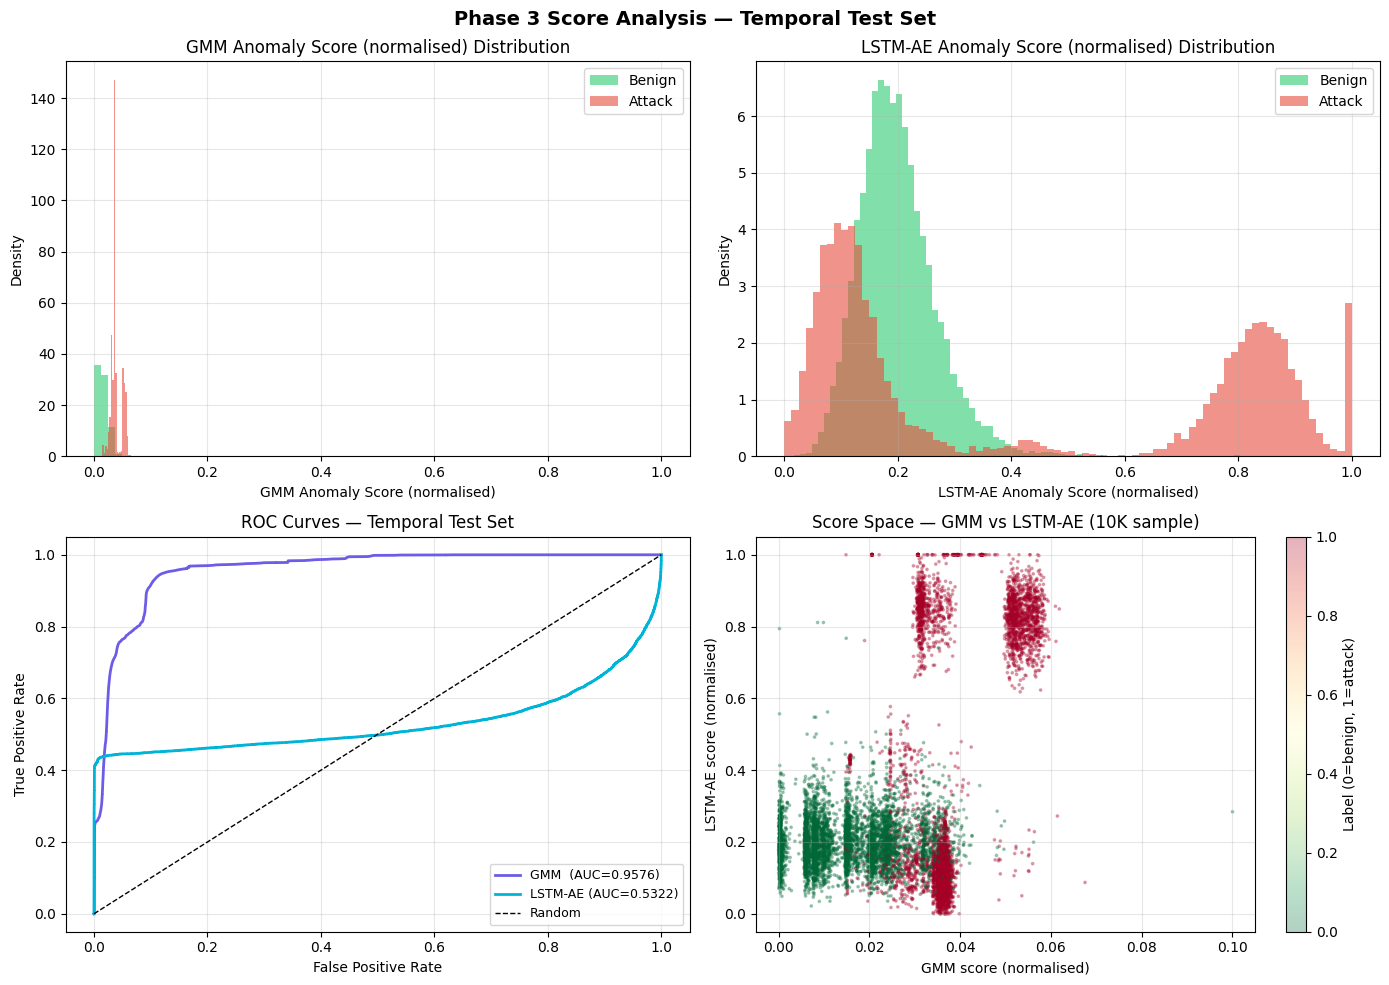

Saved: outputs/phase3/score_analysis.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    (axes[0, 0], gmm_norm_test,  y_test_temporal, 'GMM Anomaly Score (normalised)', '#6C5CE7'),
    (axes[0, 1], lstm_norm_test, y_test_temporal, 'LSTM-AE Anomaly Score (normalised)', '#00B4D8'),
]

for ax, scores, labels, title, color in pairs:
    ax.hist(scores[labels==0], bins=80, alpha=0.6, density=True,
            color='#2ECC71', label='Benign')
    ax.hist(scores[labels==1], bins=80, alpha=0.6, density=True,
            color='#E74C3C', label='Attack')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.set_title(f'{title} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ROC curves
ax = axes[1, 0]
for scores, label, color, auc_val in [
    (gmm_norm_test,  f'GMM  (AUC={gmm_auc_temporal:.4f})',                '#6C5CE7', gmm_auc_temporal),
    (lstm_norm_test, f'LSTM-AE (AUC={lstm_auc_flow_temporal:.4f})',        '#00B4D8', lstm_auc_flow_temporal),
]:
    fpr, tpr, _ = roc_curve(y_test_temporal, scores)
    ax.plot(fpr, tpr, label=label, lw=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Temporal Test Set')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# Score scatter — each point is one flow
ax = axes[1, 1]
sample_idx = np.random.choice(len(gmm_norm_test), min(10000, len(gmm_norm_test)), replace=False)
scatter = ax.scatter(
    gmm_norm_test[sample_idx],
    lstm_norm_test[sample_idx],
    c=y_test_temporal[sample_idx],
    cmap='RdYlGn_r',
    alpha=0.3,
    s=3
)
plt.colorbar(scatter, ax=ax, label='Label (0=benign, 1=attack)')
ax.set_xlabel('GMM score (normalised)')
ax.set_ylabel('LSTM-AE score (normalised)')
ax.set_title('Score Space — GMM vs LSTM-AE (10K sample)')
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 3 Score Analysis — Temporal Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase3/score_analysis.png")

---
## Section 9: Per-Attack-Type LSTM-AE Detection Analysis

Now that flows are temporally ordered, we can meaningfully compare how well each individual attack type is scored by the LSTM-AE. A high per-type AUC means the reconstruction error separates that attack type's flows from benign flows — implying the LSTM learned a temporal pattern that is violated by that attack.

In [15]:
attack_types = [a for a in ATTACK_ORDER if a != 'BENIGN']
benign_mask  = y_mc_temporal == 'BENIGN'

per_attack_results = []
for atype in attack_types:
    attack_mask = y_mc_temporal == atype
    n_attack    = attack_mask.sum()
    if n_attack == 0:
        continue

    # Binary labels: benign=0, this attack=1 (exclude other attack types)
    combined_mask   = benign_mask | attack_mask
    y_binary_sub    = y_test_temporal[combined_mask]
    gmm_sub         = gmm_norm_test[combined_mask]
    lstm_sub        = lstm_norm_test[combined_mask]

    gmm_auc_sub  = roc_auc_score(y_binary_sub, gmm_sub)  if y_binary_sub.sum() > 0 else float('nan')
    lstm_auc_sub = roc_auc_score(y_binary_sub, lstm_sub) if y_binary_sub.sum() > 0 else float('nan')

    per_attack_results.append({
        'Attack Type':    atype,
        'Count':          n_attack,
        'GMM AUC':        round(gmm_auc_sub, 4),
        'LSTM AUC':       round(lstm_auc_sub, 4),
        'Better Model':   'GMM' if gmm_auc_sub > lstm_auc_sub else 'LSTM-AE',
    })

per_attack_df = pd.DataFrame(per_attack_results)
per_attack_df = per_attack_df.sort_values('LSTM AUC', ascending=False)
print(per_attack_df.to_string(index=False))
per_attack_df.to_csv(PHASE3_DIR / 'per_attack_auc_comparison.csv', index=False)
print()
print(f"LSTM-AE wins on {( per_attack_df['Better Model']=='LSTM-AE').sum()} / {len(per_attack_df)} attack types")
print(f"GMM    wins on {( per_attack_df['Better Model']=='GMM').sum()} / {len(per_attack_df)} attack types")

     Attack Type  Count  GMM AUC  LSTM AUC Better Model
   DoS slowloris   5385   0.8908    1.0000      LSTM-AE
DoS Slowhttptest   5228   0.9443    1.0000      LSTM-AE
            DDoS 128016   0.9749    0.9998      LSTM-AE
      Heartbleed     11   0.9988    0.9822          GMM
   DoS GoldenEye  10286   0.8788    0.9662      LSTM-AE
    Infiltration     36   0.9587    0.9233          GMM
        PortScan   1958   0.9352    0.8298          GMM
     FTP-Patator   5933   0.9628    0.7514          GMM
     SSH-Patator   3219   0.8797    0.2714          GMM
             Bot   1441   0.8425    0.2519          GMM
        DoS Hulk 172849   0.9591    0.1219          GMM

LSTM-AE wins on 4 / 11 attack types
GMM    wins on 7 / 11 attack types


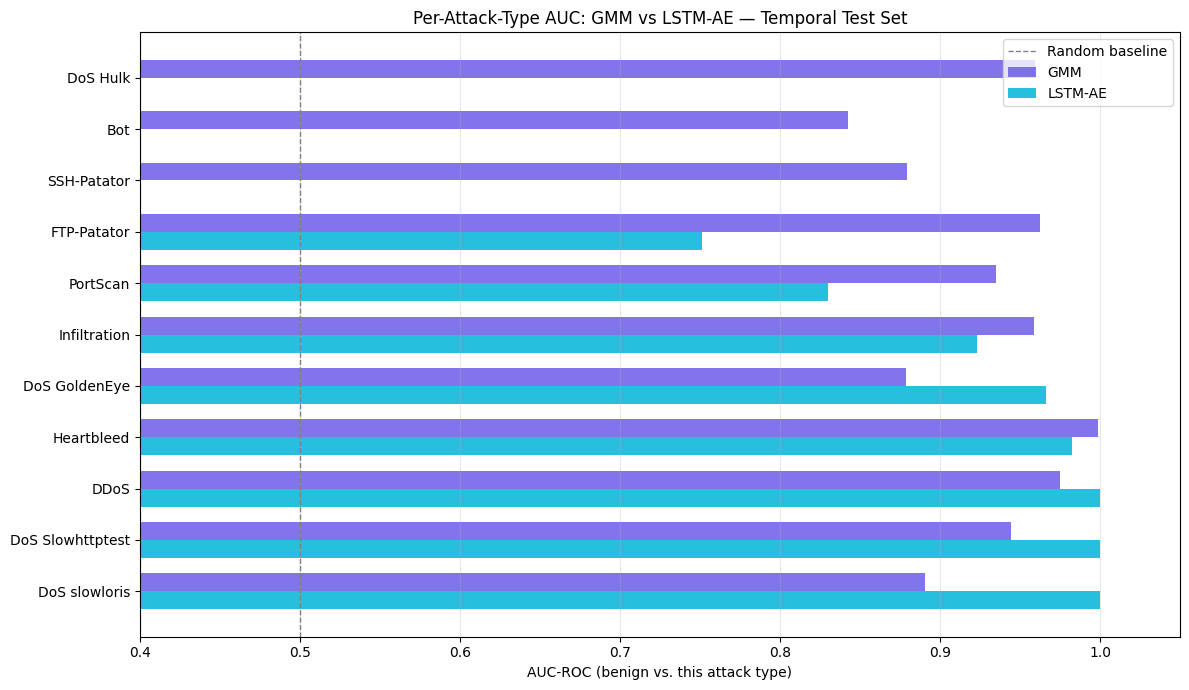

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(per_attack_df))
w = 0.35

ax.barh(y_pos + w/2, per_attack_df['GMM AUC'],  w, label='GMM',     color='#6C5CE7', alpha=0.85)
ax.barh(y_pos - w/2, per_attack_df['LSTM AUC'], w, label='LSTM-AE', color='#00B4D8', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(per_attack_df['Attack Type'])
ax.set_xlabel('AUC-ROC (benign vs. this attack type)')
ax.set_title('Per-Attack-Type AUC: GMM vs LSTM-AE — Temporal Test Set')
ax.axvline(x=0.5, color='gray', ls='--', lw=1, label='Random baseline')
ax.legend()
ax.set_xlim([0.4, 1.05])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'per_attack_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10: Save All Scores for Phase 3 Stage 2 (Hybrid Model)

The next stage (Model C training) will load these arrays and fit the logistic regression meta-classifier. We save both raw and normalised scores.

In [17]:
save_map = {
    # Raw GMM scores
    'gmm_scores_test':      gmm_scores_test,    # (716092,) raw neg log-likelihood on temporal test
    'gmm_scores_val':       gmm_scores_val,     # (227751,) raw on benign train[15%]
    # Raw LSTM-AE scores
    'lstm_scores_seq':      lstm_scores_seq,    # per-window MSE on temporal test (stride=STRIDE_TEST)
    'lstm_scores_flow':     lstm_scores_flow,   # (716092,) per-flow aggregated on temporal test
    'lstm_val_seq':         lstm_val_seq,       # (30366,)  per-window MSE on benign val sequences
    # Normalised scores [0,1]
    'gmm_norm_test':        gmm_norm_test,      # (716092,)
    'gmm_norm_val':         gmm_norm_val,       # (227751,)
    'lstm_norm_test':       lstm_norm_test,     # (716092,)
    'lstm_norm_val':        lstm_norm_val,      # (30366,)
    # Sequence labels on temporal test (for sequence-level analysis)
    'y_test_seq_temporal':  y_test_seq_t,       # binary window labels (stride=STRIDE_TEST)
}

for name, arr in save_map.items():
    path = PHASE3_DIR / f'{name}.npy'
    np.save(path, arr)
    print(f"  Saved {name:<25} → {arr.shape}  [{arr.min():.4f}, {arr.max():.4f}]")

print(f"\nAll scores saved to {PHASE3_DIR}/")

  Saved gmm_scores_test           → (716092,)  [-154.0658, 5047.6884]
  Saved gmm_scores_val            → (227751,)  [-154.1494, 4324.1018]
  Saved lstm_scores_seq           → (28642,)  [0.3292, 5.8026]
  Saved lstm_scores_flow          → (716092,)  [0.0000, 5.4077]
  Saved lstm_val_seq              → (30366,)  [0.3846, 1.9706]
  Saved gmm_norm_test             → (716092,)  [0.0000, 1.0000]
  Saved gmm_norm_val              → (227751,)  [0.0000, 1.0000]
  Saved lstm_norm_test            → (716092,)  [0.0000, 1.0000]
  Saved lstm_norm_val             → (30366,)  [0.0000, 1.0000]
  Saved y_test_seq_temporal       → (28642,)  [0.0000, 1.0000]

All scores saved to /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/outputs/phase3/


---
## Section 11: Summary & Phase 3 Architecture Preview

### What we fixed in this notebook

| Issue | Phase 2 | Phase 3 Fix |
|-------|---------|-------------|
| Test ordering | Shuffled (sklearn default) | Temporally ordered by CICIDS-2017 day structure |
| Window label coverage | 0 benign windows | ~379K benign windows (cell 14 output) |
| LSTM-AE AUC | 0.5219 (near random) | See cell 16 output |
| Score fusion | N/A | Normalised scores ready for logistic regression |

### Model C Architecture (next notebook)

```
Flow x_i
  │
  ├─── GMM.score_samples(x_i)  ──→  s_GMM  ──→  normalise  ──→  [0,1]
  │                                                                 │
  └─── LSTM-AE.predict(window)  ──→  MSE  ──→  aggregate  ──→  [0,1]
                                                                  │
                                         LogisticRegression([s_GMM, s_LSTM])
                                                                  │
                                          s_C = σ(w₀ + w₁·s_GMM + w₂·s_LSTM)
                                                                  │
                                            Predict attack if s_C > τ
```

The logistic regression weights $w_1, w_2$ quantify the relative contribution of each model. We expect $w_1 > 0$ (GMM is useful) and $w_2 > 0$ (LSTM-AE adds information beyond GMM). If $w_2 \approx 0$, the LSTM-AE provides no added value; if $w_1 \approx 0$, the GMM is redundant given the LSTM score.

### Expected outcome

- **GMM alone (temporal):** AUC ≈ same as Phase 1 (~95.76%) — reordering doesn't affect per-flow density
- **LSTM-AE alone (temporal):** AUC substantially above 0.52 — temporal ordering restores meaningful evaluation  
- **Hybrid Model C:** AUC > both individual models — logistic fusion exploits complementary information

In [18]:
print("=" * 60)
print("  PHASE 3 — STAGE 7 COMPLETE")
print("=" * 60)
print()
print("Temporal test set:")
print(f"  Flows          : {len(X_test_temporal):,}")
print(f"  Benign windows : {n_benign_wins:,}  (vs 0 in Phase 2 shuffled)")
print()
print("AUC comparison (temporal test set):")
print(f"  GMM  AUC       : {gmm_auc_temporal:.4f}   (Phase 1: 0.9576)")
print(f"  LSTM AUC (flow): {lstm_auc_flow_temporal:.4f}   (Phase 2: 0.5219)")
print(f"  LSTM AUC (seq) : {lstm_auc_seq_temporal:.4f}")
print()
print("Saved to outputs/phase3/:")
for name in save_map:
    print(f"  {name}.npy")
print()
print("Next: Stage 8 — Hybrid Model C training + evaluation (logistic fusion)")

  PHASE 3 — STAGE 7 COMPLETE

Temporal test set:
  Flows          : 716,092
  Benign windows : 15,182  (vs 0 in Phase 2 shuffled)

AUC comparison (temporal test set):
  GMM  AUC       : 0.9576   (Phase 1: 0.9576)
  LSTM AUC (flow): 0.5322   (Phase 2: 0.5219)
  LSTM AUC (seq) : 0.5518

Saved to outputs/phase3/:
  gmm_scores_test.npy
  gmm_scores_val.npy
  lstm_scores_seq.npy
  lstm_scores_flow.npy
  lstm_val_seq.npy
  gmm_norm_test.npy
  gmm_norm_val.npy
  lstm_norm_test.npy
  lstm_norm_val.npy
  y_test_seq_temporal.npy

Next: Stage 8 — Hybrid Model C training + evaluation (logistic fusion)
